### Physics 150

# Lab 7 Air Resistance and Buoyancy

Notes to Grader:  
    1. You can find my solution code in the cells below.  Their measurements need not be identicaly to mine (they probably won't) but if they differ by an order of magnitude or more then they probably have a units problem.   
    2. One common error is to underestimate the uncertainty in the radius of the helium balloon.  This leads to a prediction with an uncertainty that is smaller than it should be.  Don't grade too harsh on their prediction not agreeing with their observation unless it is off by more than about 20%. 
    
    
    
Name:
    
    
## Introduction

Last time we learned that the force of air drag is given by:

$$F_D =  {1\over 2} \; C \rho A |v| v \;\;\;\;\;(1) $$  



and used this together with Euler's method to predict the fall times for several objects. This week we will study the motion of a weather balloon and predict the time it will take for the weather balloon to rise a chosen distance.  This means that we will need to add one more force into the analysis: the buoyant force.

The balloon has a total of three forces acting on it: gravity, air drag, and a buoyant force from the surrounding air.  The downward gravitational force has three contributions: the weight of the balloon itself, the weight of the helium gas inside the balloon, and the weight of the payload attached to the balloon.  

Let's first discuss the buoyant force.  In principles of physics II you'll learn that the magnitude of the buoyant force is equal the the **weight of the displaced fluid**, which in this case is just air.  The balloon is displacing a volume of air equal to the balloon's volume.  

$$ 
F_b = m_\text{air} g = \rho_\text{air} V g
$$

Where $\phi_\text{air}$ is the density of the surrounding air and $V$ is the volume of the balloon.  Since the balloon is approximately spherical we'll use the volume of a sphere:

$$
V = {4\over 3} \pi r^3 = {1\over 6} \pi d^3
$$

The density of a gas varies with temperature and pressure according to the following formula:

$$
\rho(P,T) = \rho_0 {P \over P_0} {T_0 \over T}
$$

where $\rho_0$, $T_0$ and $P_0$ are the density, temperature, and pressure at some common point of reference.   We'll use the values corresponding to standard temperature and pressure (STP) given below:

$$
P_0 = 1.013 \times 10^5 \text{ Pa}
$$

$$
T_0 = 0^\circ \text{ C} = 273.15 \text{ K}
$$

$$
\rho_\text{air,0} = 1.2754 \text{ kg/m}^3
$$

$$
\rho_\text{He,0} = 0.1784 \text{ kg/m}^3
$$


Let's write down Newton's second law, including all of these terms and see if we can arrive at an expression for the acceleration of the balloon.

$$
F_b - F_g - F_D = m a
$$

$$
{F_b - F_g - F_D\over m} =  a
$$

where

$$
F_b = \rho_\text{air} V_\text{balloon} g
$$

$$
\begin{align*}
F_g &= m_\text{payload} g + m_\text{He} g + m_\text{balloon} g\\
&= m_\text{payload} g + \rho_\text{He} V g + m_\text{balloon} g
\end{align*}
$$

$$
F_D = {1\over 2} \rho_\text{air} A_\text{balloon} C v^2
$$

$$
\rho_\text{air} = \rho_\text{air,0} {P \over P_0} {T_0 \over T}
$$

$$
\rho_\text{He} = \rho_\text{He,0} {P \over P_0} {T_0 \over T}
$$


Here $m$ is the combined mass of the payload and the balloon. (The mass of the helium contributes a little bit but we will neglect it.)

$$
m = m_\text{payload} + m_\text{balloon}
$$



## Activity I: Modeling the balloon's motion (Euler's Method)

### Goal (Overview)
Modify your code from last week to incorporate the buoyant force experienced by the weather balloon.

### Procedure
1. Measure the mass of the balloon before we fill it with helium. Record a value and an uncertainty. 
2. We'll be adding a small payload to the balloon and adjusting it until the time of flight falls in a reasonable range.  For now, set the mass of the payload to be $m_p = 30$ grams.  We'll modify this number later.
3. Measure the temperature in the room and **assign an uncertainty to this measurement**.  Convert this temperature to Kelvins using the equation below. Then record this number in the code cell provided below.
$$ T_K = {5 \over 9}(T_F - 32) + 273.15$$
4.  Visit a weather website to look up the atmospheric pressure here in Rexburg.  You'll probably see a number with units of "inHg", which means "inches of Mercury". To convert this pressure into Pascals, use the equation below. (The $4.865$ is to undo the sea-level correction and the $3386.39$ is to convert from "inHg" to Pascals.)   Record this value in the code cell provided below. 
$$ P_\text{Pa} = 3386.39 \times (P_\text{inHg} - 4.865) $$
5. Enter values for $T_0$ $P_0$ in the code cell below using the values shown above.
6. Enter the expression for density given above into the code cell provided below for the density of air and helium.
7. Enter the expression for $V$ and $A$ in the code cell below in terms of $d$ (diameter).
8. Enter the expression for $F_b$ (the buoyant force) in the code cell below using the equation provided above.
9. Enter the expression for $F_g$ (the weights) in the code cell below using the equation provided above.
10. Enter the expression for $F_D$ (the drag force) in the code cell below using the equation provided above.  As a reminder, the equation should be:
$$
{1\over 2} \; C \rho A |v| v
$$
11. Enter the expression for $a$ (the acceleration) in the code cell below using the equation provided above.  Note that since the acceleration is not constant the calculation must be performed inside the main Euler's loop.
12. Following the same pattern from last week, add expressions to update the velocity, position, and time inside the main Euler's loop.
13. Check with your neighbor and/or B. Nelson to ensure you have done these steps correctly before moving on.
14. Have B. Nelson fill your balloon with helium.  Once it is filled, devise a method for determining the diameter of the balloon. Record the value and its uncertainty in the code cell below. (Note: The helium will slowly diffuse out of the balloon, so you won't want much time to pass between when you fill your balloon and when you test your prediction)
15. Run your code and verify that your results are reasonable.
16. Using trial and error, adjust the mass of the payload until the time of flight is in the $6-10$ seconds range.

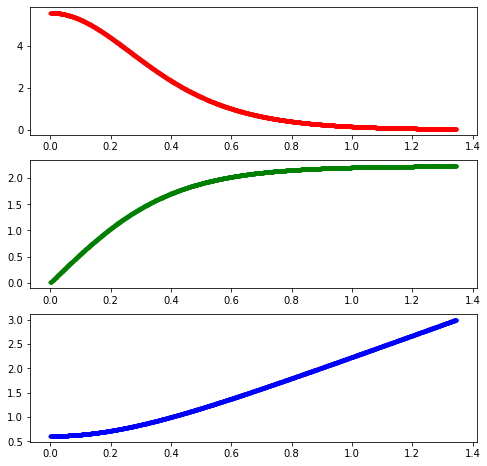

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mb = 0.05   # Mass of the balloon (kg).
mp = 0.015   # Mass of the payload (kg).
T = 21.5+273.15    # Current temperature (Kelvins).
P = 84500    # Current pressure (Pa).

ρa0 = 1.2754  # Reference density of air (kg/m^3)
ρh0 = 0.1784  # Reference density of helium (kg/m^3)

T0 = 273.15   # Reference temperature (Kelvins).
P0 = 1.0e5   # Reference Pressure (Pa).

ρa = ρa0 * (P/P0) * (T0/T)   # Density of air (kg/m^3)
ρh = ρh0 * (P/P0) * (T0/T)  # Density of Helium (kg/m^3)

d = 0.61   # Diameter of weather balloon (m).
V = 1/6 * np.pi * d**3    # Volume of balloon (m^3).
A = np.pi * (d/2)**2      # Cross-sectional area of balloon (m^3)
C = 0.5   # Drag constant for sphere (unitless)
Fb = ρa * V * g  # Buoyant Force (N).

g = 9.8  # Acceleration due to gravity (m/s^2)
mt = mp + mb + ρh * V   # Total mass (kg).

Fg = mt * g  # Weight of helium + payload + balloon (N).

dt = 0.001    # Time step (s).

y = d     # Initial height of balloon (meters)
v = 0
t = 0
yCeiling = 3.0   # Height of the ceiling (meters)

fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(3,1,1)
ax2 = fig.add_subplot(3,1,2)
ax3 = fig.add_subplot(3,1,3)
if Fb < Fg:
    print("Your balloon won't fly!")
    exit()
while y < yCeiling and t < 10:
    Fd = 1/2 * ρa * A * C * v**2
    a =  (Fb - Fd - Fg)/mt
    v = v + a * dt
    y = y + v * dt
    t = t + dt
    ax1.plot(t,a,'r.')
    ax2.plot(t,v,'g.')
    ax3.plot(t,y,'b.')
    
plt.show()
    
    
    

## Activity II: Including Uncertainty

### Goal (Overview)
Using the uncertainties that you assigned to your measured values from Activity I, use Euler's method to calculate the uncertainty in the flight time.

### Procedure
To incorporate uncertainty into Euler's method, you must repeat your Euler's loop many times using different values for those quantities that carry uncertainty.  In the code cell below you will find a template for doing this.  Follow the instructions below to complete the task.
1. You'll notice that the variable names in the code cell have been modified from what they were in Activity I. Instead of "mb" for mass of the balloon, we now have "meanmb" for mean mass of the balloon and "dmb" for uncertainty in the mass of the balloon. Transfer all of your measurements and uncertainties from Activity I into the code cell below.
2. If you haven't yet, record the uncertainties in all of your measured values in the code cell below.
3. You'll notice that our Euler's loop from Activity I is now enclosed in another loop (called a 'for' loop).  This will allow us to repeat the Euler's loop as many times as we would like. We call the Euler's loop the "inner" loop and the 'for' loop the "outer" loop. The first six lines in the outer loop are to select a random number for each of the variables that carry uncertainty.  I've given an example of how to do this on the first line for the balloon mass.  Repeat this same process to select random numbers for the other five quantities that carry uncertainty.
4. Fill in the correct expressions for the remainder of the code lines that are incomplete.  (Most of these lines will be identical to what they were in Activity I.)
5. Check with a neighbor or B. Nelson to verify that you did it correctly.
6. Run your code and observe the results. Notice the spread in travel times depicted on the position vs. time graph. (Cool eh!)

Note: The uncertainty in your balloon diameter will be the biggest contributor to the uncertainty in the predicted flight time.  


7.981999999999874 2.5389399362725626


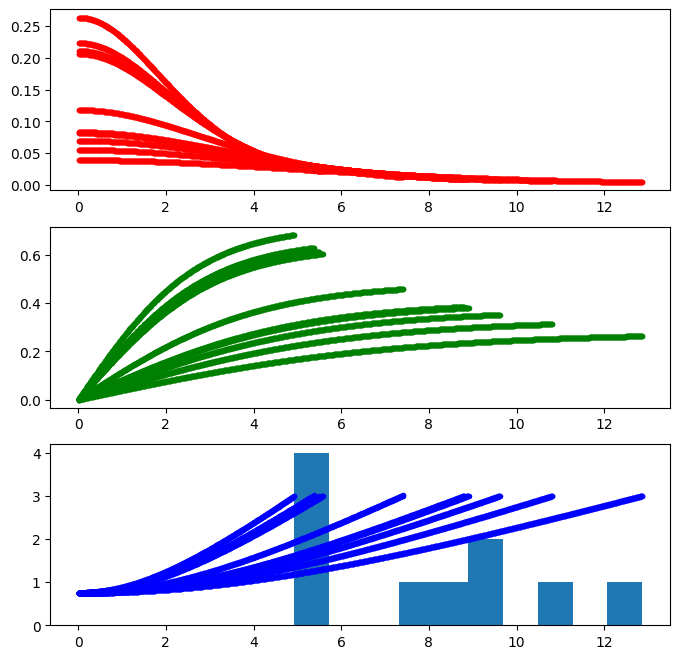

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Variables with uncertainties attached.
meanmb = 0.042   # Mass of the balloon (kg).
dmb = 0.001   # Uncertainty in balloon mass (kg).

meanT = 21.5+273.15    # Current temperature (Kelvins).
dT = 0.5         # Uncertainty in current temperature (Kelvins).

meanP = 84500    # Current pressure (Pa).
dP = 50          # Uncertainty in current atmospheric pressure (Pa).

meand = 0.75   # Diameter of weather balloon (m).
dd =    0.005       # Uncertainty in diameter of balloon (m).

meanyCeiling = 3.0   # Height of the ceiling (meters)
dyCeiling = 0.01


# Variables with no uncertainty attached

mp = 0.145    # Mass of the payload
ρa0 = 1.2754  # Reference density of air (kg/m^3)
ρh0 = 0.1784  # Reference density of helium (kg/m^3)

T0 = 273.15   # Reference temperature (Kelvins).
P0 = 1.0e5   # Reference Pressure (Pa).

C = 0.5   # Drag constant for sphere (unitless)
g = 9.8  # Acceleration due to gravity (m/s^2)
dt = 0.01    # Time step (s).


fig = plt.figure(figsize = (8,8))
ax1 = fig.add_subplot(3,1,1)
ax2 = fig.add_subplot(3,1,2)
ax3 = fig.add_subplot(3,1,3)

times = []
N = 0
Ntrials = 10
while N < Ntrials:#for i in range(N):
    mb = np.random.uniform(meanmb - dmb,meanmb + dmb)  # Get a randon number for the balloon mass.
    d = np.random.uniform(meand - dd,meand + dd)
    P = np.random.uniform(meanP - dP,meanP + dP)
    T = np.random.uniform(meanT - dT,meanT + dT)
    yCeiling = np.random.uniform(meanyCeiling - dyCeiling,meanyCeiling + dyCeiling)

    V = 1/6 * np.pi * d**3    # Volume of balloon (m^3).
    A = np.pi * (d/2)**2      # Cross-sectional area of balloon (m^3)

    ρa = ρa0 * (P/P0) * (T0/T)   # Density of air (kg/m^3)
    ρh = ρh0 * (P/P0) * (T0/T)  # Density of Helium (kg/m^3)
    mt = mb + mp + ρh * V
    Fb = ρa * V * g  # Buoyant Force (N).
    Fg = mt * g  # Weight of helium + payload + balloon (N).

    y = d     # Initial height of balloon (meters).
    v = 0     # Initial velocity of balloon (m/s).
    t = 0     # Initial time (s).
    if Fb < Fg:  # If the weight is too big, don't run Euler's method
        print("Your buoyant force is smaller than the weight of the balloon, skipping to next iteration.")
        continue
    N += 1
    while y < yCeiling:
        Fd = 1/2 * ρa * A * C * abs(v) * v
        a =  (Fb - Fd - Fg)/mt
        v = v + a * dt
        y = y + v * dt
        t = t + dt
        ax1.plot(t,a,'r.')
        ax2.plot(t,v,'g.')
        ax3.plot(t,y,'b.')
    times.append(t)
print(np.mean(times), np.std(times))
plt.hist(times)
plt.show()
    

## Activity III: Checking our Prediction

### Goal (Overview):
The balloon will be released and allowed to accelerate upwards towards the ceiling. The flight time will be measured and compared against the predicted flight time from Activity II.
### Procedure
1. Transfer the average flight time calculated in Activity II with its associated uncertainty into the table below.
2. Release the balloon from your pre-selected initial height and use a stopwatch to time the flight. Repeat the flight at least 5 times and calculate the average and standard deviation of the mean of your data. Record the mean and standard deviation of the mean in the table below.
3. Calculate the percent error and include that number in the table.
4. It's possible that your percent error is high and the most likely explanation is in the measurement of the balloon diameter.  If this is the case, return to your code from activity II and investigate what the balloon diameter would need to be to reduce the percent error to $< 10\%$.

|--| Flight Time (s)| Uncertainty (s) |
|-------|-----------------------|-----|
|Predicted|       |              |
|Measured |       |              |
|Percent Error |       |              |



